# Peldaño 1 — Monte Carlo puro

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas  
**Autor:** Jorge Rodríguez Lázaro  
**Última actualización:** 2026-06-19

---

## Objetivo del peldaño

Este notebook construye desde cero la intuición del **método de Monte Carlo** mediante tres ejercicios sobre problemas con respuesta conocida. Usamos problemas resueltos (π, el TCL) precisamente porque conocer la respuesta exacta nos permite **validar el método**: si funciona donde sabemos lo que tiene que salir, podemos confiar en él donde no lo sabemos.

El objetivo real es:

1. Ver cómo **el azar bien empleado** resuelve problemas deterministas.
2. Cuantificar el **error estadístico** del estimador y observar su comportamiento.
3. Construir las dos piezas conceptuales que sostendrán todo el resto del proyecto: **la simulación repetida + el promedio** (Monte Carlo) y **la trayectoria aleatoria** (random walk → movimiento browniano).

## Estructura

| Sección | Tema | Conexión con el proyecto |
|---------|------|-----------------------------|
| 1 | Estimación de π por Monte Carlo | El "hola mundo" del método. Introduce convergencia y error estándar. |
| 2 | Paseo aleatorio unidimensional | Base intuitiva del movimiento browniano (Peldaño 2). |
| 3 | Teorema Central del Límite en simulación | Justifica por qué promediar simulaciones funciona y por qué la velocidad de convergencia es $O(1/\sqrt{N})$. |

## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 1.
- Robert, C. P. & Casella, G. (2004). *Monte Carlo Statistical Methods*, cap. 1–2.

---

# Sección 1 — Estimación de π por Monte Carlo

## 1.1 Planteamiento geométrico

Consideremos el cuadrado $Q = [-1, 1] \times [-1, 1]$ y el círculo unidad $C = \{(x,y) \in \mathbb{R}^2 : x^2 + y^2 \le 1\}$ inscrito en él.

- **Área del cuadrado:** $\text{Área}(Q) = 2 \cdot 2 = 4$
- **Área del círculo:** $\text{Área}(C) = \pi \cdot 1^2 = \pi$

Por el principio de Laplace continuo (probabilidad geométrica):

$$
\mathbb{P}\big((U, V) \in C\big) = \frac{\text{Área}(C)}{\text{Área}(Q)} = \frac{\pi}{4}
$$

donde $(U, V)$ es un punto elegido **uniformemente al azar** en $Q$.

## 1.2 De la geometría a la probabilidad

Repetimos el experimento $N$ veces. En cada repetición $i$ generamos un punto aleatorio $(U_i, V_i)$ uniforme en $Q$ y definimos la variable indicadora:

$$
Z_i = \mathbf{1}\{U_i^2 + V_i^2 \le 1\}
$$

$Z_i$ es una función del punto aleatorio $(U_i, V_i)$ y por tanto es ella misma una variable aleatoria. Como solo toma valores en $\{0, 1\}$, es una **Bernoulli** de parámetro $p = \pi/4$:

$$
Z_i = \begin{cases} 1 & \text{si } (U_i, V_i) \in C \\ 0 & \text{si } (U_i, V_i) \notin C \end{cases}
\qquad \mathbb{E}[Z_i] = p = \frac{\pi}{4}
$$

Las variables $Z_1, Z_2, \ldots, Z_N$ son **i.i.d.** (independientes porque cada punto se genera de forma independiente; idénticamente distribuidas porque todas siguen la misma Bernoulli($\pi/4$)).

## 1.3 Ley de los Grandes Números y estimador

Sea $\bar{Z}_N = \frac{1}{N}\sum_{i=1}^{N} Z_i$ el promedio muestral. Por la **LGN débil** (Khinchin), para todo $\varepsilon > 0$:

$$
\mathbb{P}\!\left(\left|\bar{Z}_N - \frac{\pi}{4}\right| < \varepsilon\right) \xrightarrow{N \to \infty} 1
$$

Es decir, para cualquier $\varepsilon$ fijo por pequeño que sea, la probabilidad de que el promedio esté a menos de $\varepsilon$ de $\pi/4$ tiende a 1 conforme $N \to \infty$. La **LGN fuerte** (Borel–Cantelli) refuerza esto a convergencia casi segura:

$$
\bar{Z}_N \xrightarrow{\text{c.s.}} \frac{\pi}{4}
$$

Despejando, el **estimador de Monte Carlo** para π es:

$$
\boxed{\hat{\pi}_N = 4\,\bar{Z}_N = \frac{4}{N}\sum_{i=1}^{N} \mathbf{1}\{U_i^2 + V_i^2 \le 1\}}
$$

## 1.4 ¿Qué precisión esperamos?

$\hat{\pi}_N$ es una variable aleatoria con varianza finita. Usando $\text{Var}(Z_i) = p(1-p)$ con $p = \pi/4$:

$$
\text{Var}(\hat{\pi}_N) = 16 \cdot \frac{\text{Var}(Z_i)}{N} = \frac{16\,p(1-p)}{N} = \frac{\pi(4-\pi)}{N}
$$

Y su **error estándar** (desviación típica del estimador):

$$
\text{SE}(\hat{\pi}_N) = \sqrt{\frac{\pi(4-\pi)}{N}} \approx \frac{1.642}{\sqrt{N}}
$$

**Lectura práctica:** para reducir el error a la mitad hay que **cuadruplicar** $N$. Ese ritmo $O(1/\sqrt{N})$ es la velocidad de convergencia característica de Monte Carlo — lenta, pero independiente de la dimensión del problema, lo que lo hace único para problemas de alta dimensión.

## 1.4 Implementación

Empezamos importando lo necesario y fijando una semilla para que los resultados sean reproducibles.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generador de números pseudoaleatorios moderno de NumPy.
# Fijamos semilla para que el notebook sea 100% reproducible.
rng = np.random.default_rng(seed=42)

## 1.5 Implementación vectorizada

Generamos los N puntos **todos a la vez** como arrays de NumPy en lugar de usar un bucle Python. Esto es entre 10 y 100 veces más rápido y es el estilo estándar en computación científica.

In [3]:
def estimar_pi(N, rng):
    U = rng.uniform(-1, 1, N)       # N coordenadas x uniformes en [-1, 1] --> Array de las coordenadas x
    V = rng.uniform(-1, 1, N)       # N coordenadas y uniformes en [-1, 1] --> Array de las coordenadas y
    dentro = (U**2 + V**2) <= 1     # True si el punto cae dentro del círculo --> vector de Zi 
    return 4 * np.mean(dentro)      # Z̄_N * 4 = estimación de π

## 1.6 Primera prueba: ¿converge a π?

Llamamos a `estimar_pi` con distintos valores de N y comparamos cada estimación con el valor real de π junto al error estándar teórico derivado en la sección 1.4.

In [4]:
PI_REAL = np.pi

valores_N = [100, 1_000, 10_000, 100_000, 1_000_000]

print(f"{'N':>10}  {'π estimado':>12}  {'error real':>12}  {'SE teórico':>12}")
print("-" * 52)

for N in valores_N:
    estimacion = estimar_pi(N, rng)
    error_real = abs(estimacion - PI_REAL)
    se_teorico = np.sqrt(np.pi * (4 - np.pi) / N)
    print(f"{N:>10,}  {estimacion:>12.6f}  {error_real:>12.6f}  {se_teorico:>12.6f}")

         N    π estimado    error real    SE teórico
----------------------------------------------------
       100      3.120000      0.021593      0.164218
     1,000      3.068000      0.073593      0.051930
    10,000      3.132800      0.008793      0.016422
   100,000      3.143920      0.002327      0.005193
 1,000,000      3.143664      0.002071      0.001642


## 1.7 Visualizaciones

### Gráfico 1 — Distribución de puntos

2000 puntos generados uniformemente en el cuadrado, coloreados según si caen dentro (azul) o fuera (rojo) del círculo. La proporción de puntos azules es aproximadamente π/4.

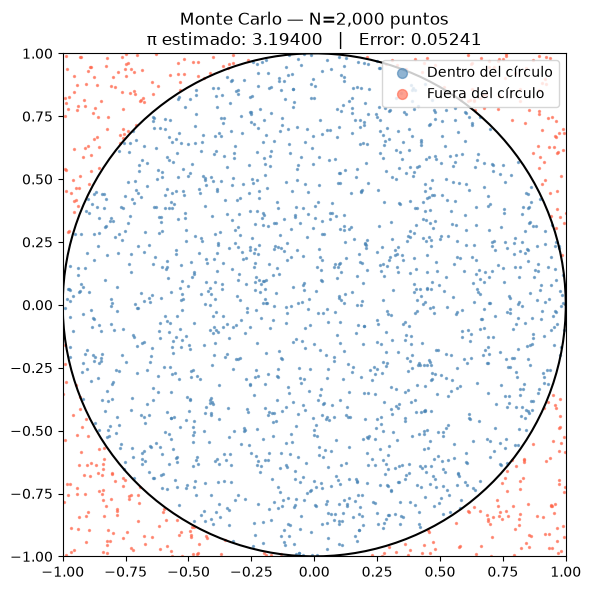

In [5]:
N_viz = 2_000
U_viz = rng.uniform(-1, 1, N_viz)
V_viz = rng.uniform(-1, 1, N_viz)
dentro_viz = (U_viz**2 + V_viz**2) <= 1
pi_viz = 4 * np.mean(dentro_viz)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(U_viz[dentro_viz],  V_viz[dentro_viz],  s=2, color='steelblue', alpha=0.6, label='Dentro del círculo')
ax.scatter(U_viz[~dentro_viz], V_viz[~dentro_viz], s=2, color='tomato',    alpha=0.6, label='Fuera del círculo')
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1.5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo — N={N_viz:,} puntos\nπ estimado: {pi_viz:.5f}   |   Error: {abs(pi_viz - np.pi):.5f}')
ax.legend(markerscale=5, loc='upper right')
plt.tight_layout()
plt.show()

### Gráfico 2 — Convergencia del estimador

Error real para 60 valores de N en escala logarítmica, comparado con el SE teórico. En escala log-log, ambas curvas deberían seguir una recta de pendiente −1/2, la firma del ritmo O(1/√N).

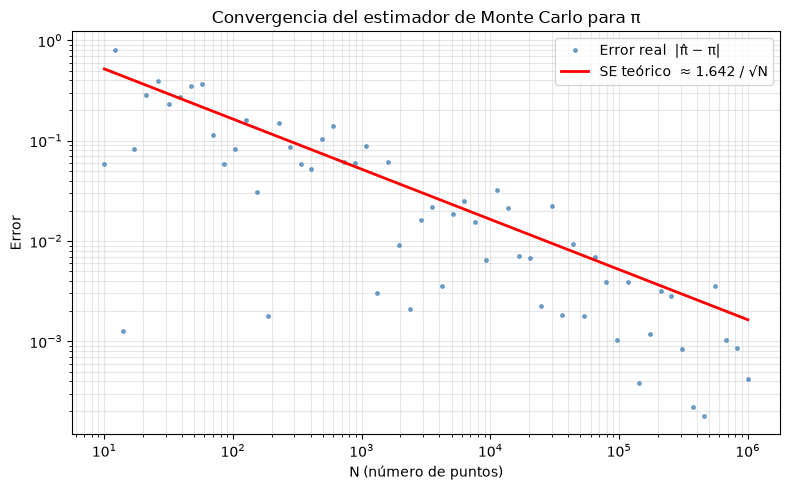

In [6]:
N_vals  = np.unique(np.logspace(1, 6, 60).astype(int))
errores = np.array([abs(estimar_pi(N, rng) - np.pi) for N in N_vals])
se_vals = np.sqrt(np.pi * (4 - np.pi) / N_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_vals, errores, '.', color='steelblue', alpha=0.7, markersize=5, label='Error real  |π̂ − π|')
ax.loglog(N_vals, se_vals, 'r-', linewidth=2,                               label='SE teórico  ≈ 1.642 / √N')
ax.set_xlabel('N (número de puntos)')
ax.set_ylabel('Error')
ax.set_title('Convergencia del estimador de Monte Carlo para π')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.8 Cierre de la sección — balance honesto

### Resultados obtenidos

El estimador de Monte Carlo $\hat{\pi}_N = 4\bar{Z}_N$ satisface las siguientes propiedades:

- **Consistencia:** por la LGN fuerte (Kolmogorov), $\hat{\pi}_N \xrightarrow{\text{c.s.}} \pi$ cuando $N \to \infty$, dado que las $Z_i$ son i.i.d. con $\mathbb{E}[Z_i] = \pi/4 < \infty$.
- **Insesgadez:** $\mathbb{E}[\hat{\pi}_N] = \pi$ para todo $N$ finito, al ser $\hat{\pi}_N = 4\bar{Z}_N$ y $\mathbb{E}[\bar{Z}_N] = \pi/4$.
- **Tasa de convergencia:** $\text{SE}(\hat{\pi}_N) = \sqrt{\pi(4-\pi)/N} = O(N^{-1/2})$, confirmado empíricamente mediante el gráfico log-log de la sección 1.7.

### Limitaciones

**Velocidad de convergencia.** El ritmo $O(N^{-1/2})$ es intrínseco a cualquier estimador de Monte Carlo basado en $N$ muestras i.i.d. — es consecuencia directa del Teorema Central del Límite (sección 3). Para reducir el error en un orden de magnitud se requiere incrementar $N$ en dos órdenes. Métodos de cuadratura deterministas (e.g. integración de Gauss-Legendre) alcanzan tasas de convergencia exponencial en dimensión baja, lo que los hace superiores para este problema unidimensional concreto.

**Naturaleza estocástica.** $\hat{\pi}_N$ es una variable aleatoria: dos ejecuciones con distintas semillas producen estimaciones distintas. Toda estimación de Monte Carlo debe ir acompañada de su error estándar para ser interpretable; un único número sin cuantificación de la incertidumbre carece de valor estadístico.

**Alcance del ejemplo.** La estimación de $\pi$ se emplea aquí como banco de pruebas del método, no como aplicación de interés práctico. Su valor reside en que la solución exacta es conocida, permitiendo validar tanto la implementación como la fórmula del error estándar. La ventaja competitiva de Monte Carlo se manifiesta en problemas de alta dimensión o con integrales sin forma cerrada, donde los métodos deterministas resultan inviables.

### Estructura general del método

Esta sección ilustra el esquema canónico de Monte Carlo, que se repetirá en los peldaños sucesivos:

$$
\mu = \mathbb{E}[f(X)] \approx \frac{1}{N}\sum_{i=1}^{N} f(X_i), \qquad X_i \overset{\text{i.i.d.}}{\sim} \mathbb{P}_X
$$

En la Sección 1, $f = \mathbf{1}_C$ y $\mu = \pi/4$. En el Peldaño 3, $f$ será el payoff descontado de una opción europea y $\mu$ su precio justo bajo la medida de riesgo neutral — el mismo esquema con una función de mayor complejidad financiera.